# SVM Classifier Model

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import svm
#from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_validate, GridSearchCV, KFold, cross_val_score
#from sklearn.metrics import recall_score

#from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler



In [ ]:
MODEL_INPUT_FILE = "model_input_traintest_10krandselfpeps_hla-extended_m2_t5.csv"#"model_input_imm_and_mhc-nb_m1_t7.csv"#"#"model_input_all_traintest.csv"
ALL_PEPS_FILE    = "data/input/cedar_allPeps_traintest.txt"
IMM_PEP_FILE     = "data/input/cedar_imm_peps_traintest.txt"
NON_IMM_PEP_FILE = "data/input/cedar_non_imm_peps_traintest.txt"#randselfpeps~10k.txt"#randselfpeps~10k.txt"#random_in_silico_peptides.txt"#non_mhc_binding_peptides.txt"#"

## Load the Data

In [150]:
X_df = pd.read_csv(MODEL_INPUT_FILE)

display(X_df[X_df['peptide'].str.contains('pep')])

,peptide,hla_best_rank,PRIME_%Rank_bestAllele,pathogenicity,selfsimilarity,mtec_expression,tap_score


In [151]:
X_df.drop_duplicates(subset=['peptide'], inplace=True)
X_df.sort_values(by='peptide', inplace=True)

display(X_df)
display(X_df.shape)

,peptide,hla_best_rank,PRIME_%Rank_bestAllele,pathogenicity,selfsimilarity,mtec_expression,tap_score
0,AAAAAAAAL,0.001,0.012,0.664286,0.985714,1,0.7737
1,AAAAAAGVL,0.018,0.056,0.602740,0.890411,1,0.5886
2,AAAAAALYY,0.004,0.013,0.697987,0.818792,0,0.9958
3,AAAAAAQQIQV,0.279,2.033,0.441176,0.848740,0,0.4028
4,AAAAAAVAA,0.043,0.078,0.742857,0.914286,1,0.3309
...,...,...,...,...,...,...,...
29177,YYVFHMPRCL,0.020,0.142,0.417266,0.586331,0,0.7886
29178,YYVGYLQPRTF,0.014,0.279,1.000000,0.814332,0,0.9316
29179,YYVHEGIRTY,0.005,0.039,1.000000,0.717742,0,0.9371
29180,YYYAGSSRL,0.003,0.080,1.000000,0.786517,0,0.7838


(29182, 7)

In [152]:
immPeps, non_immPeps = set(), set()

def addPeps(fp: str, pepSet: set):
    with open(fp, 'r') as f:
        for line in f:
            if line:
                pepSet.add(line.strip())

addPeps(IMM_PEP_FILE, immPeps)
addPeps(NON_IMM_PEP_FILE, non_immPeps)

print(f'SIZE BEFORE DEDUP: {len(non_immPeps)}')
non_immPeps -= immPeps
print(f'SIZE AFTER DEDUP: {len(non_immPeps)}')

labels_df = pd.DataFrame([
    {'peptide': pep, 'immunogenic': 1} for pep in immPeps
] + [
    {'peptide': pep, 'immunogenic': 0} for pep in non_immPeps
])

labels_df.sort_values(by='peptide', inplace=True)
labels_df.drop_duplicates(subset=['peptide'], inplace=True)
print(labels_df.shape)
labels_to_drop = set(labels_df['peptide']) - set(X_df['peptide'])
labels_df = labels_df[~labels_df['peptide'].isin(labels_to_drop)]
print(labels_df.shape)


display(labels_df.head(3))
display(labels_df.tail(3))

# Ensure peptides in feature df match those in the label df
label_peps = immPeps.copy()
label_peps.update(non_immPeps)
X_df = X_df[X_df['peptide'].isin(label_peps)]
print(X_df.shape)
X_df.drop_duplicates(subset=['peptide'], inplace=True)
print(X_df.shape)
print(f"Immunogenic: {len(immPeps)}")
print(f"randSelfPeps: {len(non_immPeps)}")

SIZE BEFORE DEDUP: 9836
SIZE AFTER DEDUP: 9836
(19499, 2)
(19499, 2)


,peptide,immunogenic
9594,AAAAAAGVL,1
16843,AAAAAAQQIQV,0
5027,AAAAAAVAA,1


,peptide,immunogenic
4556,YYVHEGIRTY,1
2825,YYYAGSSRL,1
12580,YYYRFVIGL,0


(19499, 7)
(19499, 7)
Immunogenic: 9663
randSelfPeps: 9836


In [153]:
X = X_df.drop(columns='peptide').to_numpy()
display(X)
y = labels_df.drop(columns='peptide').to_numpy()
y=y.ravel()

display(y)

array([[0.018     , 0.056     , 0.60273975, 0.89041096, 1.        ,
        0.5886    ],
       [0.279     , 2.033     , 0.44117647, 0.8487395 , 0.        ,
        0.4028    ],
       [0.043     , 0.078     , 0.74285716, 0.91428572, 1.        ,
        0.3309    ],
       ...,
       [0.005     , 0.039     , 1.        , 0.71774191, 0.        ,
        0.9371    ],
       [0.003     , 0.08      , 1.        , 0.78651685, 0.        ,
        0.7838    ],
       [0.011     , 0.006     , 0.61497325, 0.7326203 , 0.        ,
        0.8062    ]], shape=(19499, 6))

array([1, 0, 1, ..., 1, 1, 0], shape=(19499,))

### Visualize data

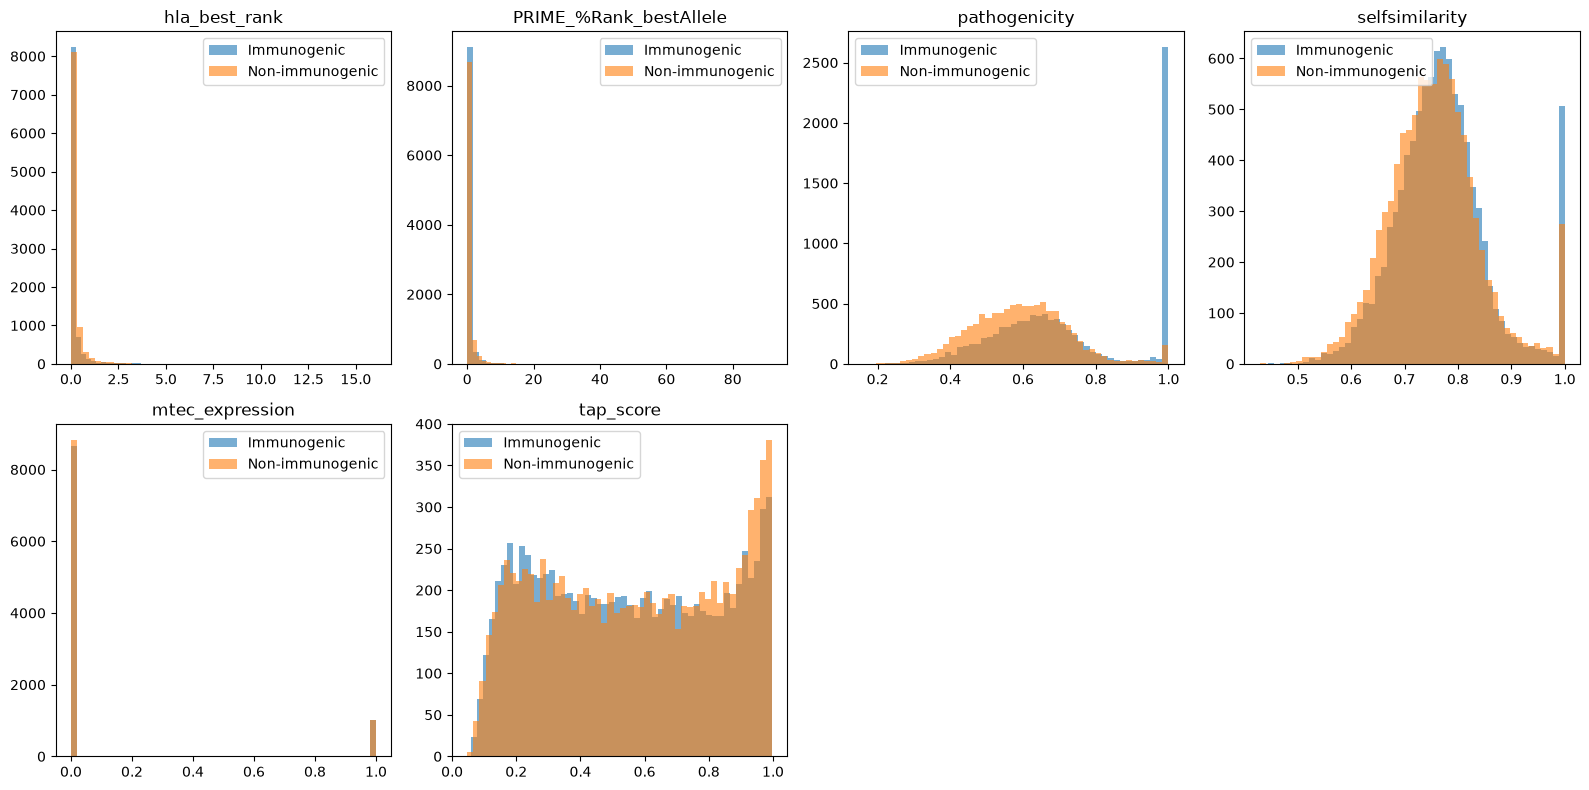

In [154]:
feature_cols = X_df.drop(columns='peptide').columns

def plotHistograms(X, feature_cols):
    fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
    axes = axes.flatten()

    for i, feature in enumerate(feature_cols):
        axes[i].hist(X[y == 1, i], bins=50, alpha=0.6, label='Immunogenic')
        axes[i].hist(X[y == 0, i], bins=50, alpha=0.6, label='Non-immunogenic')
        axes[i].set_title(feature)
        axes[i].legend()

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plotHistograms(X, feature_cols)

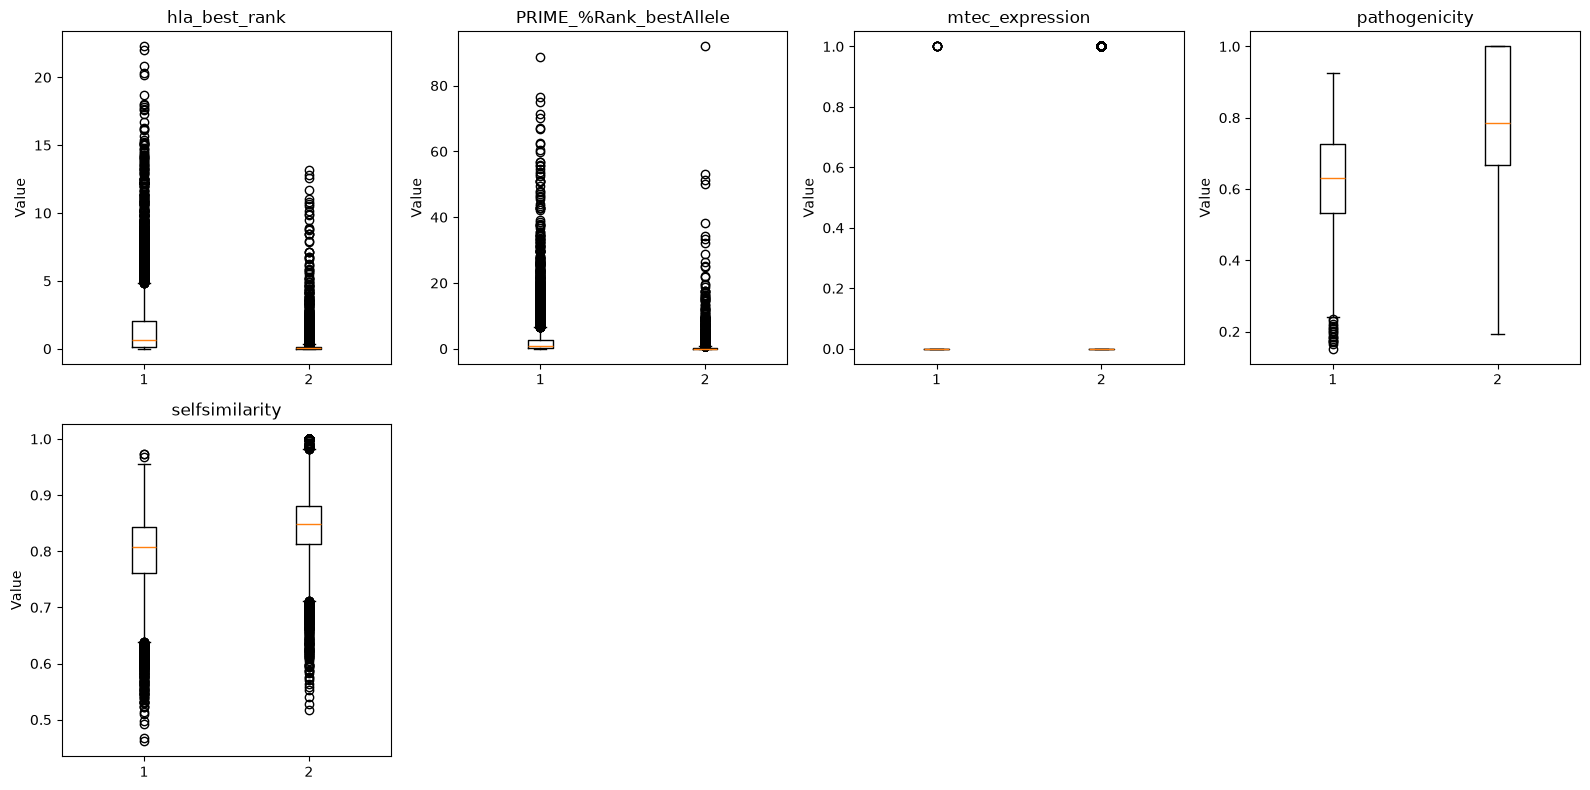

In [43]:
def plotBoxplots(X, feature_cols):
    fig, axes = plt.subplots(nrows=len(feature_cols) // 4 + 1, ncols=4, figsize=(16, 4 * (len(feature_cols) // 4 + 1)))
    axes = axes.flatten()

    for i, feature in enumerate(feature_cols):
        data = [X[y == 0, i], X[y == 1, i]]
        axes[i].boxplot(data, label=['Non-immunogenic', 'Immunogenic'])
        axes[i].set_title(feature)
        axes[i].set_ylabel('Value')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plotBoxplots(X, feature_cols)

### Feature Scaling

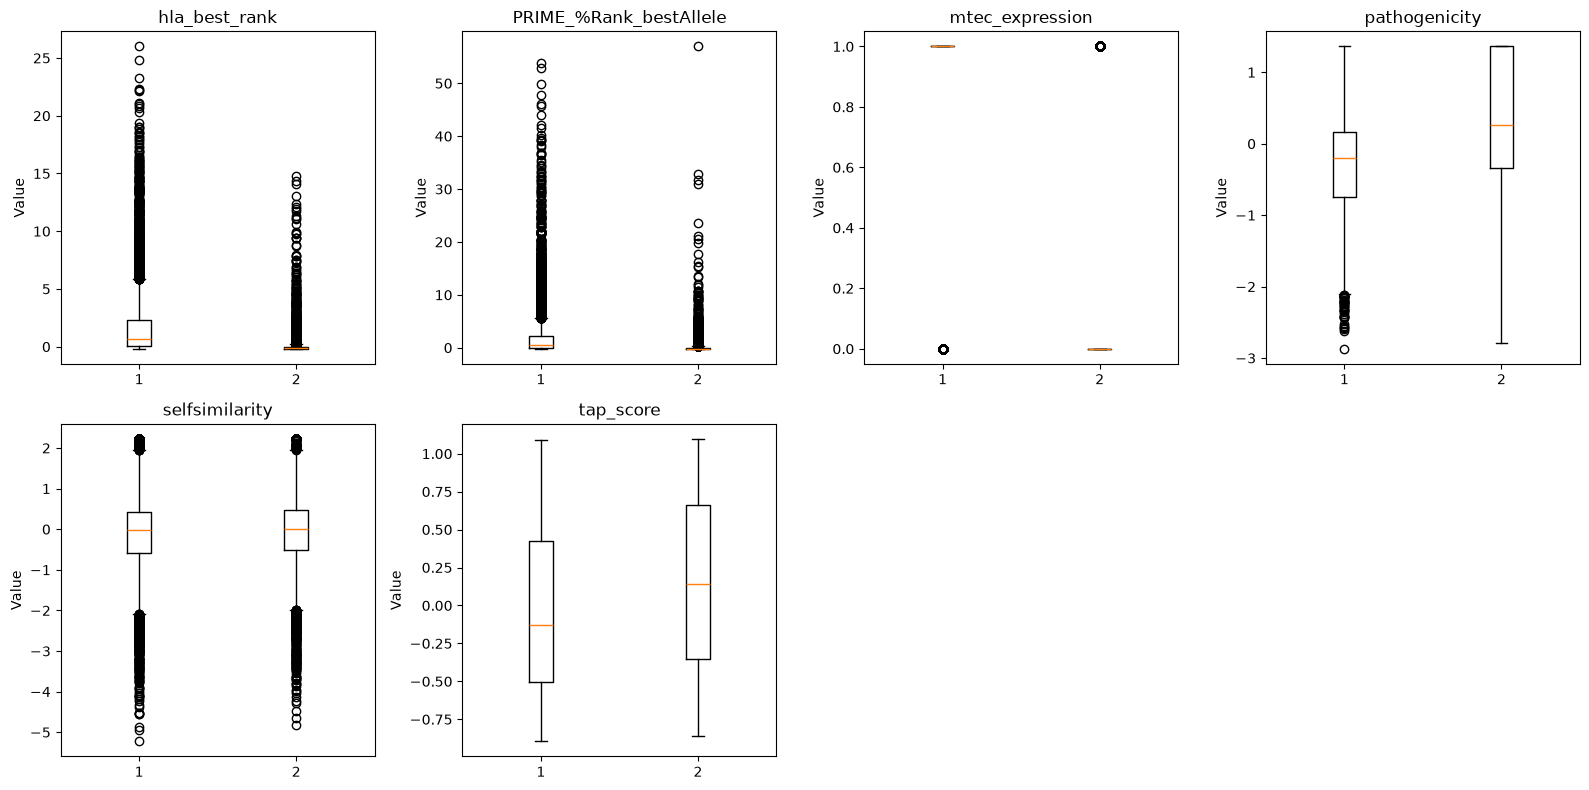

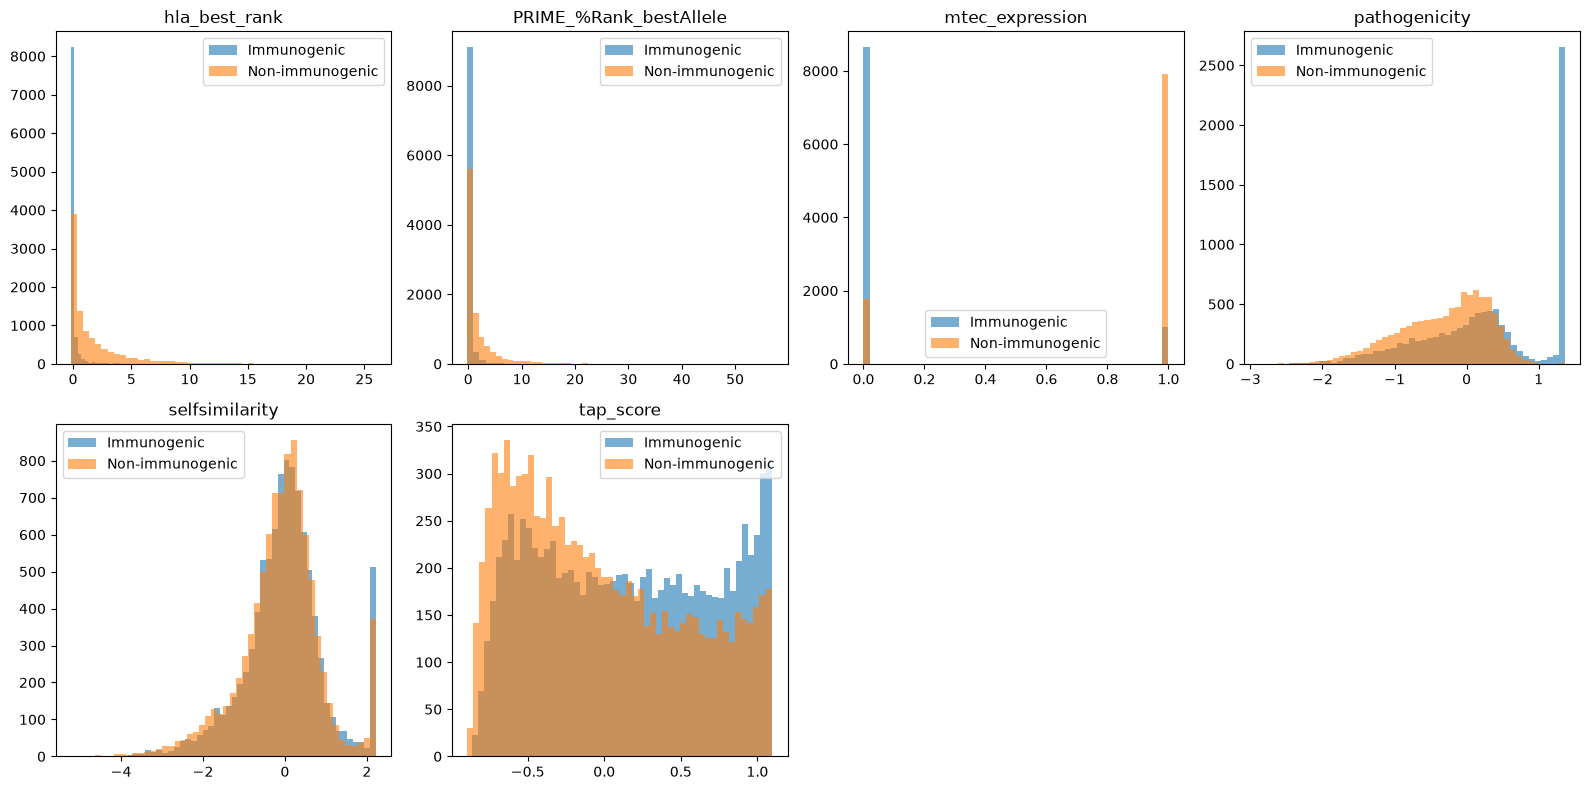

In [71]:
transformer = RobustScaler().fit(X)
X_scaled_Robust = transformer.transform(X)

plotBoxplots(X_scaled_Robust, feature_cols)
plotHistograms(X_scaled_Robust, feature_cols)

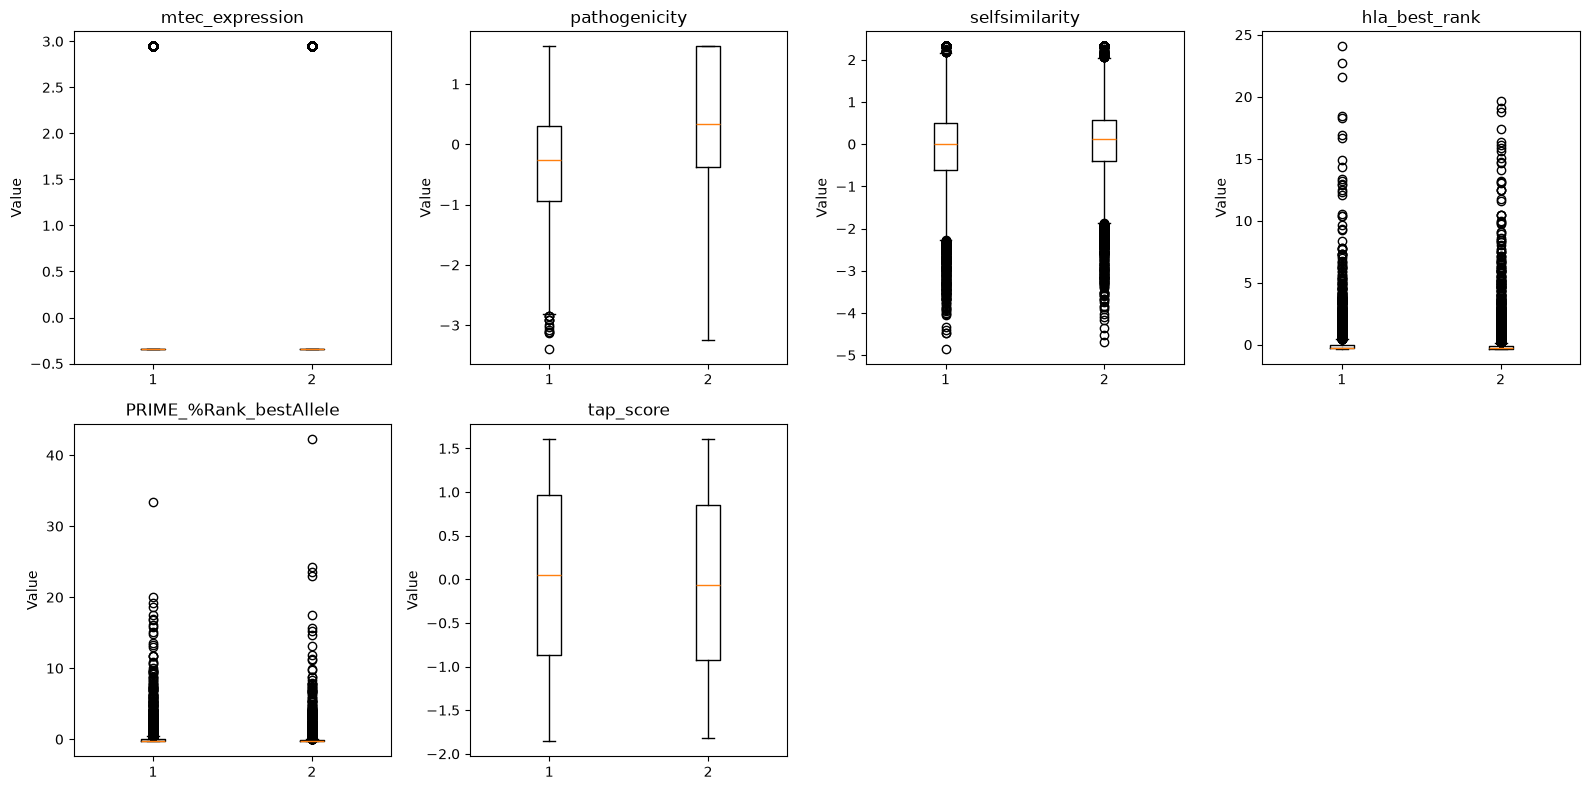

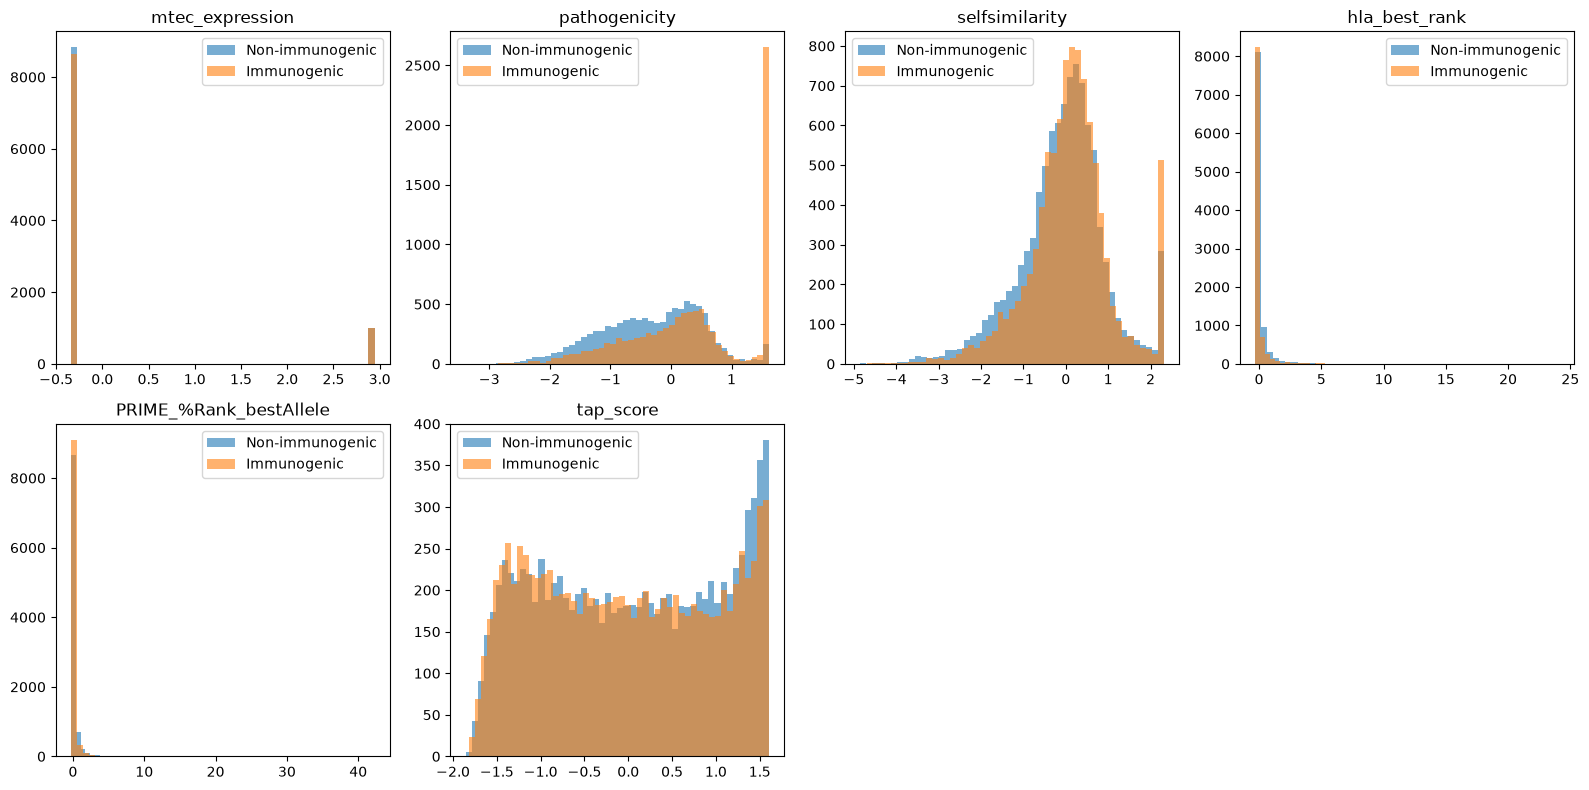

In [93]:
transformer = StandardScaler().fit(X)
X_scaled_Standard = transformer.transform(X)

plotBoxplots(X_scaled_Standard, feature_cols)
plotHistograms(X_scaled_Standard, feature_cols)

## SVM

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(f"X_train: {X_train.shape}")
display(f"X_test: {X_test.shape}")
display(f"y_train: {y_train.shape}")
display(f"y_test: {y_test.shape}")

X_scaled_train, X_scaled_test, y_train, y_test = train_test_split(X_scaled_Robust, y, test_size=0.2, random_state=42)

'X_train: (15599, 6)'

'X_test: (3900, 6)'

'y_train: (15599,)'

'y_test: (3900,)'

In [135]:
# C = 1.0  # SVM regularization parameter
# models = (
#     svm.SVC(kernel="linear", C=C),
#     svm.LinearSVC(C=C, max_iter=10000),
#     svm.SVC(kernel="rbf", gamma=0.7, C=C),
#     svm.SVC(kernel="poly", degree=3, gamma="auto", C=C),
# )
# models = (clf.fit(X, y) for clf in models)

scoring = ['precision_macro', 'recall_macro']
clf = svm.SVC(kernel='linear', C=10, random_state=0)
scores = cross_validate(clf, X, y, scoring=scoring, n_jobs=-1)
sorted(scores.keys())

scoring = ['precision_macro', 'recall_macro']
clf = svm.SVC(kernel='linear', C=10, random_state=0)
scores_scaled = cross_validate(clf, X_scaled_Robust, y, scoring=scoring, n_jobs=-1)


In [136]:
print("All scaled data")

display(f"Precision: {scores['test_precision_macro']}")
display(f"Recall: {scores['test_recall_macro']}")
display("Scaled")
display(f"Precision: {scores_scaled['test_precision_macro']}")
display(f"Recall: {scores_scaled['test_recall_macro']}")

All scaled data


'Precision: [0.62978977 0.61819265 0.62378088 0.65329847 0.65126857]'

'Recall: [0.62592292 0.61435005 0.61693157 0.64564712 0.64572788]'

'Scaled'

'Precision: [0.62930394 0.61819265 0.62408171 0.65329847 0.65191616]'

'Recall: [0.62540559 0.61435005 0.61718576 0.64564712 0.64623166]'

In [133]:
print("Training set only")

display(f"Precision: {scores['test_precision_macro']}")
display(f"Recall: {scores['test_recall_macro']}")
display("Scaled")
display(f"Precision: {scores_scaled['test_precision_macro']}")
display(f"Recall: {scores_scaled['test_recall_macro']}")

Training set only


'Precision: [0.64674388 0.6396074  0.63045844 0.62471908 0.65272898]'

'Recall: [0.63916121 0.6334891  0.62456274 0.61911674 0.64554966]'

'Scaled'

'Precision: [0.64674388 0.6396074  0.63045844 0.62471908 0.65235163]'

'Recall: [0.63916121 0.6334891  0.62456274 0.61911674 0.6452324 ]'

In [ ]:
# Number of random trials
NUM_TRIALS = 3

# Set up possible values of parameters to optimize over
p_grid = {"C": [1, 10, 100], "gamma": [0.01, 0.1]}

# We will use a Support Vector Classifier with "rbf" kernel
svc = svm.SVC(kernel="rbf")

# Arrays to store scores
nested_scores = np.zeros(NUM_TRIALS)

# Loop for each trial
for i in range(NUM_TRIALS):
    # Choose cross-validation techniques for the inner and outer loops,
    # independently of the dataset.
    # E.g "GroupKFold", "LeaveOneOut", "LeaveOneGroupOut", etc.
    inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
    outer_cv = KFold(n_splits=4, shuffle=True, random_state=i)

    # Nested CV with parameter optimization
    clf = GridSearchCV(estimator=svc, param_grid=p_grid, cv=inner_cv)
    nested_score = cross_val_score(clf, X=X_scaled_train, y=y_train, cv=outer_cv)
    nested_scores[i] = nested_score.mean()

array([0.64363186, 0.64331055, 0.64234886])

In [121]:
print(X_scaled_train.shape)
print(y_train.shape)

from sklearn.utils import resample
X_sample, y_sample = resample(X_scaled_train, y_train, n_samples=500, random_state=42)


(15599, 6)
(15599,)


In [ ]:
from sklearn import svm
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# Parameter grid: each dict is its own independent search space,
# so gamma is only tested with kernels that actually use it.
# ------------------------------------------------------------------
p_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10]},
    {"svc__kernel": ["rbf"],    "svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1]},
    #{"svc__kernel": ["poly"],   "svc__C": [0.1, 1, 10], "svc__gamma": [0.01, 0.1, 1], "svc__degree": [2, 3]},
]

# ------------------------------------------------------------------
# Wrap in a Pipeline. Best practice even if scaling is already done —
# it also makes adding preprocessing steps later trivial.
# The svc__ prefix in p_grid above maps to the pipeline step name.
# ------------------------------------------------------------------
pipe = Pipeline([("svc", svm.SVC())])

# ------------------------------------------------------------------
# Nested CV — single pass, no repeated trials
# ------------------------------------------------------------------
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)
outer_cv  = KFold(n_splits=5, shuffle=True, random_state=42)

clf = GridSearchCV(
    estimator=pipe,
    param_grid=p_grid,
    cv=inner_cv,
    scoring="accuracy",
    n_jobs=-1,
    refit=True,                    # refit best model on the full inner fold data
    return_train_score=True,       # lets you diagnose overfitting later
    verbose=1
)

nested_scores = cross_val_score(clf, X=X_sample, y=y_sample, cv=outer_cv, scoring="accuracy")

print(f"Nested CV accuracy: {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Nested CV accuracy: 0.6180 ± 0.0360


In [130]:
# ------------------------------------------------------------------
# Identify the best hyperparameters: refit GridSearchCV on the 
# full training set so you can inspect best_params_ and best_score_
# ------------------------------------------------------------------
clf.fit(X_sample, y_sample)

print(f"\nBest params:  {clf.best_params_}")
print(f"Best inner CV score: {clf.best_score_:.4f}")

# ------------------------------------------------------------------
# Summary table of all candidates — useful for comparing kernels
# ------------------------------------------------------------------
results_df = pd.DataFrame(clf.cv_results_)[
    ["param_svc__kernel", "param_svc__C", "param_svc__gamma", "param_svc__degree",
     "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
].sort_values("rank_test_score")

print("\nTop 10 parameter combinations:")
print(results_df.head(10).to_string(index=False))

print("\nBottom 10 parameter combinations:")
print(results_df.tail(10).to_string(index=False))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best params:  {'svc__C': 10, 'svc__kernel': 'linear'}
Best inner CV score: 0.6360

Top 10 parameter combinations:
param_svc__kernel  param_svc__C  param_svc__gamma  param_svc__degree  mean_test_score  std_test_score  mean_train_score  rank_test_score
           linear          10.0               NaN                NaN            0.636        0.018547            0.6465                1
           linear           1.0               NaN                NaN            0.632        0.016000            0.6425                2
           linear           0.1               NaN                NaN            0.626        0.028705            0.6375                3
              rbf          10.0              0.01                NaN            0.624        0.025768            0.6720                4
              rbf           1.0              0.01                NaN            0.618        0.044000            0.6375                5
 